In [31]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, Model
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve,auc
import random
import matplotlib.pyplot as plt

In [2]:
X = np.load("../data/X.npy")
y_user = np.load("../data/y_user.npy")
y_act = np.load("../data/y_act.npy")

print("X:", X.shape)
print("Users:", np.unique(y_user))
print("Activities:", len(np.unique(y_act)))

X: (3521, 300, 90)
Users: [0 1 2 3 6 7 8 9]
Activities: 16


In [3]:
unknown_user = 7  # değiştirebilirsin

train_mask = y_user != unknown_user
unknown_mask = y_user == unknown_user

X_train_all = X[train_mask]
y_user_train_all = y_user[train_mask]
y_act_train_all = y_act[train_mask]

X_unknown = X[unknown_mask]
y_unknown = y_user[unknown_mask]

print("Train users:", np.unique(y_user_train_all))
print("Unknown samples:", X_unknown.shape)

Train users: [0 1 2 3 6 8 9]
Unknown samples: (480, 300, 90)


In [4]:
#Train/validation ayıralım
X_train, X_val, y_user_train, y_user_val, y_act_train, y_act_val = train_test_split(
    X_train_all,
    y_user_train_all,
    y_act_train_all,
    test_size=0.2,
    stratify=y_user_train_all,
    random_state=42
)

print("Train:", X_train.shape)
print("Val:", X_val.shape)


Train: (2432, 300, 90)
Val: (609, 300, 90)


In [ ]:
input_layer = layers.Input(shape=(300, 90))

# Backbone
x = layers.Conv1D(64, 5, padding='same', activation='relu')(input_layer)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling1D(2)(x)

x = layers.Conv1D(128, 3, padding='same', activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling1D(2)(x)

x = layers.Conv1D(256, 3, padding='same', activation='relu')(x)
x = layers.BatchNormalization()(x)

x = layers.GlobalAveragePooling1D()(x)

# Activity Head (embedding'den değil!)
activity_output = layers.Dense(16, activation='softmax', name="activity_head")(x)

# Embedding Head
embedding = layers.Dense(128)(x)
embedding = layers.Lambda(lambda t: tf.nn.l2_normalize(t, axis=1),
                          name="embedding_head")(embedding)

model = Model(inputs=input_layer,
              outputs=[activity_output, embedding])

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 300, 90)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 300, 64)   │     28,864 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 300, 64)   │        256 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 150, 64)   │          0 │ batch_normalizat… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 150, 128)  │     24,704 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 150, 128)  │        512 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_1     │ (None, 75, 128)   │          0 │ batch_normalizat… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 75, 256)   │     98,560 │ max_pooling1d_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 75, 256)   │      1,024 │ conv1d_2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 256)       │          0 │ batch_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │     32,896 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activity_head       │ (None, 16)        │      4,112 │ global_average_p… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_head      │ (None, 128)       │          0 │ dense[0][0]       │
│ (Lambda)            │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 190,928 (745.81 KB)

 Trainable params: 190,032 (742.31 KB)

 Non-trainable params: 896 (3.50 KB)

In [6]:
#Loss Fonk.
cross_entropy = tf.keras.losses.SparseCategoricalCrossentropy()

def triplet_loss(anchor, positive, negative, margin=0.7):
    pos_dist = tf.reduce_sum(tf.square(anchor - positive), axis=1)
    neg_dist = tf.reduce_sum(tf.square(anchor - negative), axis=1)
    return tf.reduce_mean(tf.maximum(pos_dist - neg_dist + margin, 0.0))

In [7]:
#Triplet Batch Generator
def generate_triplet_batch(X, y_user, y_act, batch_size=32):
    anchors, positives, negatives, act_labels = [], [], [], []
    unique_users = np.unique(y_user)

    for _ in range(batch_size):
        user = random.choice(unique_users)
        user_indices = np.where(y_user == user)[0]

        neg_user = random.choice(unique_users[unique_users != user])
        neg_indices = np.where(y_user == neg_user)[0]

        a, p = np.random.choice(user_indices, 2, replace=False)
        n = np.random.choice(neg_indices)

        anchors.append(X[a])
        positives.append(X[p])
        negatives.append(X[n])
        act_labels.append(y_act[a])

    return (
        np.array(anchors),
        np.array(positives),
        np.array(negatives),
        np.array(act_labels)
    )

In [8]:
#Training step
optimizer = tf.keras.optimizers.Adam(1e-4)
lambda_weight = 0.8

@tf.function
def train_step(anchor, positive, negative, act_labels):
    with tf.GradientTape() as tape:

        act_pred_anchor, emb_anchor = model(anchor, training=True)
        _, emb_positive = model(positive, training=True)
        _, emb_negative = model(negative, training=True)

        act_loss = cross_entropy(act_labels, act_pred_anchor)
        tri_loss = triplet_loss(emb_anchor, emb_positive, emb_negative)

        total_loss = act_loss + lambda_weight * tri_loss

    grads = tape.gradient(total_loss, model.trainable_variables)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))

    return total_loss, act_loss, tri_loss


In [9]:
def generate_hard_triplet_batch(X, y_user, y_act, batch_size=32):
    
    indices = np.random.choice(len(X), batch_size, replace=False)
    
    batch_X = X[indices]
    batch_user = y_user[indices]
    batch_act = y_act[indices]
    
    # Embedding hesapla
    _, embeddings = model(batch_X, training=False)
    embeddings = embeddings.numpy()
    
    anchors, positives, negatives, act_labels = [], [], [], []
    
    for i in range(batch_size):
        anchor_emb = embeddings[i]
        anchor_user = batch_user[i]
        
        # Positive candidates
        pos_indices = np.where(batch_user == anchor_user)[0]
        pos_indices = pos_indices[pos_indices != i]
        
        if len(pos_indices) == 0:
            continue
        
        pos_embs = embeddings[pos_indices]
        pos_dists = np.sum((anchor_emb - pos_embs)**2, axis=1)
        hard_pos = pos_indices[np.argmax(pos_dists)]
        
        # Negative candidates
        neg_indices = np.where(batch_user != anchor_user)[0]
        neg_embs = embeddings[neg_indices]
        neg_dists = np.sum((anchor_emb - neg_embs)**2, axis=1)
        hard_neg = neg_indices[np.argmin(neg_dists)]
        
        anchors.append(batch_X[i])
        positives.append(batch_X[hard_pos])
        negatives.append(batch_X[hard_neg])
        act_labels.append(batch_act[i])
    
    return (
        np.array(anchors),
        np.array(positives),
        np.array(negatives),
        np.array(act_labels)
    )

In [10]:
#Training loss
EPOCHS = 25
BATCH_SIZE = 16
STEPS_PER_EPOCH = 50

for epoch in range(EPOCHS):
    total_l, act_l, tri_l = 0, 0, 0

    for step in range(STEPS_PER_EPOCH):
        a, p, n, y_a = generate_hard_triplet_batch(
            X_train, y_user_train, y_act_train, BATCH_SIZE
        )

        t, a_l, tr_l = train_step(a, p, n, y_a)

        total_l += t.numpy()
        act_l += a_l.numpy()
        tri_l += tr_l.numpy()

    print(f"\nEpoch {epoch+1}")
    print("Total:", total_l/STEPS_PER_EPOCH)
    print("Activity:", act_l/STEPS_PER_EPOCH)
    print("Triplet:", tri_l/STEPS_PER_EPOCH)


Epoch 1
Total: 3.1714048
Activity: 2.7462878
Triplet: 0.5313955

Epoch 2
Total: 2.791043
Activity: 2.4701176
Triplet: 0.40115687

Epoch 3
Total: 2.5448463
Activity: 2.2685752
Triplet: 0.34533933

Epoch 4
Total: 2.3888607
Activity: 2.1910753
Triplet: 0.24723108

Epoch 5
Total: 2.2086883
Activity: 2.0457923
Triplet: 0.20361967

Epoch 6
Total: 2.0503068
Activity: 1.9247206
Triplet: 0.15698259

Epoch 7
Total: 1.9389294
Activity: 1.8173975
Triplet: 0.15191543

Epoch 8
Total: 1.8750472
Activity: 1.7462219
Triplet: 0.16103107

Epoch 9
Total: 1.8722378
Activity: 1.7295245
Triplet: 0.17839193

Epoch 10
Total: 1.7012631
Activity: 1.5926139
Triplet: 0.13581134

Epoch 11
Total: 1.6317773
Activity: 1.5444778
Triplet: 0.109124616

Epoch 12
Total: 1.5063249
Activity: 1.4358563
Triplet: 0.088085964

Epoch 13
Total: 1.4946373
Activity: 1.4326664
Triplet: 0.07746347

Epoch 14
Total: 1.4970388
Activity: 1.4170749
Triplet: 0.09995497

Epoch 15
Total: 1.4604496
Activity: 1.3620869
Triplet: 0.12295304

Epo

In [11]:
#Trainden gallery oluşturalım
_, train_embeddings = model(X_train)

gallery = {}
for user in np.unique(y_user_train):
    gallery[user] = np.mean(
        train_embeddings[y_user_train == user],
        axis=0
    )

In [12]:
def identify(sample_embedding, gallery, threshold=0.62):
    sims = {u: np.dot(sample_embedding, gallery[u]) for u in gallery}
    best_user = max(sims, key=sims.get)

    if sims[best_user] > threshold:
        return best_user
    else:
        return -1

In [13]:
_, val_embeddings = model(X_val)

correct = 0
for i in range(len(val_embeddings)):
    pred = identify(val_embeddings[i], gallery)
    if pred == y_user_val[i]:
        correct += 1

print("Known Acceptance:", correct / len(val_embeddings))

Known Acceptance: 0.9014778325123153


In [14]:
_, unknown_embeddings = model(X_unknown)

rejected = 0
for emb in unknown_embeddings:
    pred = identify(emb, gallery)
    if pred == -1:
        rejected += 1

print("Unknown Rejection:", rejected / len(unknown_embeddings))

Unknown Rejection: 0.5604166666666667


In [15]:
sims_known = []

for i in range(len(val_embeddings)):
    sims = {u: np.dot(val_embeddings[i], gallery[u]) for u in gallery}
    sims_known.append(max(sims.values()))

print("Known similarity mean:", np.mean(sims_known))
print("Known similarity min :", np.min(sims_known))
print("Known similarity max :", np.max(sims_known))

Known similarity mean: 0.7583695
Known similarity min : 0.3820358
Known similarity max : 0.9148838


In [16]:
sims_unknown = []

for emb in unknown_embeddings:
    sims = {u: np.dot(emb, gallery[u]) for u in gallery}
    sims_unknown.append(max(sims.values()))

print("Unknown similarity mean:", np.mean(sims_unknown))
print("Unknown similarity max :", np.max(sims_unknown))

Unknown similarity mean: 0.51833034
Unknown similarity max : 0.76855934


In [17]:
thresholds = np.arange(0.40, 0.75, 0.02)

for t in thresholds:
    # Known
    correct_known = 0
    for i in range(len(val_embeddings)):
        sims = {u: np.dot(val_embeddings[i], gallery[u]) for u in gallery}
        best_user = max(sims, key=sims.get)
        if sims[best_user] > t and best_user == y_user_val[i]:
            correct_known += 1

    known_acc = correct_known / len(val_embeddings)

    # Unknown
    correct_unknown = 0
    for emb in unknown_embeddings:
        sims = {u: np.dot(emb, gallery[u]) for u in gallery}
        best_user = max(sims, key=sims.get)
        if sims[best_user] <= t:
            correct_unknown += 1

    unknown_rej = correct_unknown / len(unknown_embeddings)

    print(f"Threshold {t:.2f} → Known: {known_acc:.3f} | Unknown: {unknown_rej:.3f}")

Threshold 0.40 → Known: 0.977 | Unknown: 0.317
Threshold 0.42 → Known: 0.977 | Unknown: 0.321
Threshold 0.44 → Known: 0.974 | Unknown: 0.321
Threshold 0.46 → Known: 0.974 | Unknown: 0.329
Threshold 0.48 → Known: 0.969 | Unknown: 0.333
Threshold 0.50 → Known: 0.967 | Unknown: 0.344
Threshold 0.52 → Known: 0.957 | Unknown: 0.367
Threshold 0.54 → Known: 0.951 | Unknown: 0.406
Threshold 0.56 → Known: 0.947 | Unknown: 0.442
Threshold 0.58 → Known: 0.941 | Unknown: 0.471
Threshold 0.60 → Known: 0.918 | Unknown: 0.506
Threshold 0.62 → Known: 0.901 | Unknown: 0.560
Threshold 0.64 → Known: 0.867 | Unknown: 0.623
Threshold 0.66 → Known: 0.824 | Unknown: 0.679
Threshold 0.68 → Known: 0.783 | Unknown: 0.775
Threshold 0.70 → Known: 0.724 | Unknown: 0.877
Threshold 0.72 → Known: 0.644 | Unknown: 0.950
Threshold 0.74 → Known: 0.562 | Unknown: 0.994


In [18]:
final_threshold = 0.46

In [19]:
# Known acceptance
correct_known = 0
for i in range(len(val_embeddings)):
    sims = {u: np.dot(val_embeddings[i], gallery[u]) for u in gallery}
    best_user = max(sims, key=sims.get)

    if sims[best_user] > final_threshold and best_user == y_user_val[i]:
        correct_known += 1

known_acc = correct_known / len(val_embeddings)

# Unknown rejection
correct_unknown = 0
for emb in unknown_embeddings:
    sims = {u: np.dot(emb, gallery[u]) for u in gallery}
    best_user = max(sims, key=sims.get)

    if sims[best_user] <= final_threshold:
        correct_unknown += 1

unknown_rej = correct_unknown / len(unknown_embeddings)

print("Known Acceptance :", known_acc)
print("Unknown Rejection:", unknown_rej)
print("Balanced Score   :", (known_acc + unknown_rej) / 2)

Known Acceptance : 0.9737274220032841
Unknown Rejection: 0.32916666666666666
Balanced Score   : 0.6514470443349754


In [20]:
act_pred, _ = model(X_val)
act_acc = np.mean(np.argmax(act_pred, axis=1) == y_act_val)
print("Activity Accuracy:", act_acc)

Activity Accuracy: 0.6978653530377669


In [28]:
# Known test embeddings üret

_, known_embeddings = model(X_val)   # X_val = bilinen kullanıcı validation/test verisi
known_embeddings = known_embeddings.numpy()

print("Known embeddings shape:", known_embeddings.shape)

Known embeddings shape: (609, 128)


In [29]:
known_sims= []
unknown_sims= []

#Known test
for emb in known_embeddings:
    sims = [np.dot(emb,gallery[user]) for user in gallery]
    known_sims.append(max(sims))
    
#Unknown test 
for emb in unknown_embeddings:
    sims = [np.dot(emb,gallery[user]) for user in gallery]
    unknown_sims.append(max(sims))
        
known_sims = np.array(known_sims)
unknown_sims = np.array(unknown_sims)

print("Known mean:",known_sims.mean())
print("Unknown mean:",unknown_sims.mean())


Known mean: 0.7583695
Unknown mean: 0.51833034


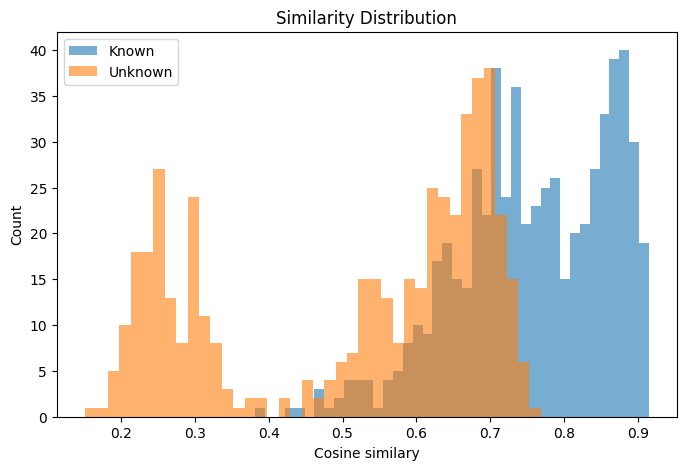

In [30]:
plt.figure(figsize=(8,5))

plt.hist(known_sims,bins=40,alpha=0.6,label="Known")
plt.hist(unknown_sims,bins=40,alpha=0.6,label="Unknown")

plt.legend()
plt.xlabel("Cosine similary")
plt.ylabel("Count")
plt.title("Similarity Distribution")
plt.show()


In [32]:
#1 =Known ,0 =unknown

labels= np.concatenate([
    np.ones(len(known_sims)),
    np.zeros(len(unknown_sims))
])

scores = np.concatenate([known_sims,unknown_sims])

fpr,tpr,thresholds = roc_curve(labels,scores)
roc_auc = auc(fpr,tpr)

print("auc:",roc_auc)

auc: 0.886182950191571


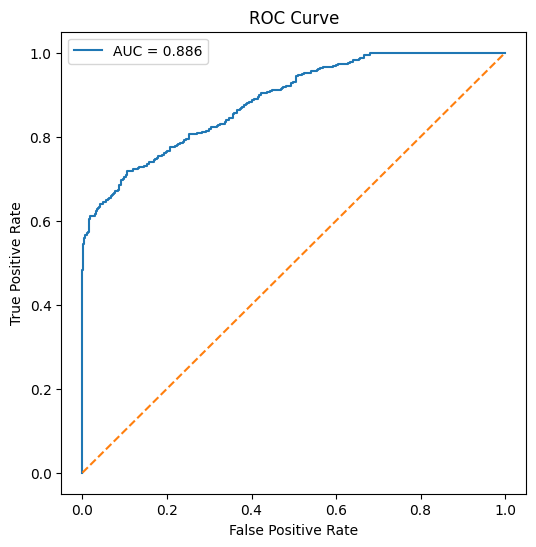

In [33]:
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [34]:
#EEr hesaplama
fnr = 1-tpr
eer_index = np.nanargmin(np.abs(fpr-fnr))

eer = fpr[eer_index]
eer_threshold = thresholds[eer_index]

print("EER:",eer)
print("EER Threshold:",eer_threshold)

EER: 0.22291666666666668
EER Threshold: 0.68149054


In [35]:
final_threshold = eer_threshold

# Known acceptance
correct_known = 0
for emb in known_embeddings:
    sims = [np.dot(emb, gallery[u]) for u in gallery]
    if max(sims) > final_threshold:
        correct_known += 1

known_acc_eer = correct_known / len(known_embeddings)

# Unknown rejection
correct_unknown = 0
for emb in unknown_embeddings:
    sims = [np.dot(emb, gallery[u]) for u in gallery]
    if max(sims) <= final_threshold:
        correct_unknown += 1

unknown_rej_eer = correct_unknown / len(unknown_embeddings)

print("EER Threshold Performance")
print("Known Acceptance:", known_acc_eer)
print("Unknown Rejection:", unknown_rej_eer)
print("Balanced Score:", (known_acc_eer + unknown_rej_eer)/2)

EER Threshold Performance
Known Acceptance: 0.7783251231527094
Unknown Rejection: 0.7791666666666667
Balanced Score: 0.778745894909688
